# AI-Powered Email & SMS Spam Detection System

###
A practical NLP and machine learning project that classifies email and SMS text into Spam or Not Spam using a TF-IDF vectorization pipeline and a linear Support Vector Machine (LinearSVC) classifier. The system includes data cleaning, exploratory text analysis, model benchmarking, and hyperparameter optimization. The final trained pipeline is serialized for deployment and integrated into a recruiter-friendly Streamlit interface with interactive prediction, sample text generation, and documentation controls.

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

In [2]:
# -------------------------------------
# 1. Load Dataset
# -------------------------------------
df = pd.read_csv("spam mail.csv")
df.columns = df.columns.str.strip()  # remove column spacing issues if any

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset Loaded Successfully!
Shape: (5572, 2)
  Category                                           Masseges
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [3]:
import pandas as pd
import re
import string

# Load data
df = pd.read_csv("spam mail.csv")
df.columns = df.columns.str.strip()

# Rename columns correctly
df = df.rename(columns={"Masseges": "email", "Category": "label"})

print("Before Cleaning:")
print(df["label"].value_counts(), "\n")

# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove URLs
    text = re.sub(r"\S+@\S+", "", text)  # remove email IDs inside content
    text = re.sub(r"\d+", "", text)  # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

# Apply cleaning
df["clean_email"] = df["email"].apply(clean_text)

# Remove empty messages if any
df = df[df["clean_email"] != ""]

# Remove duplicates
df = df.drop_duplicates(subset=["clean_email"])

# Normalize labels
df["label"] = df["label"].astype(str).str.lower().str.strip()
df["label"] = df["label"].replace({"ham": "not_spam"})

print("After Cleaning:")
print(df["label"].value_counts())
print("Dataset shape:", df.shape)

# Save cleaned file
df.to_csv("cleaned_spam_mail.csv", index=False)
print("\nCleaned dataset saved as: cleaned_spam_mail.csv")


Before Cleaning:
label
ham     4825
spam     747
Name: count, dtype: int64 

After Cleaning:
label
not_spam    4496
spam         594
Name: count, dtype: int64
Dataset shape: (5090, 3)

Cleaned dataset saved as: cleaned_spam_mail.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset you saved
df = pd.read_csv("cleaned_spam_mail.csv")
print("Columns:", df.columns.tolist())


Columns: ['label', 'email', 'clean_email']



Email Type Distribution:
 label
not_spam    4496
spam         594
Name: count, dtype: int64


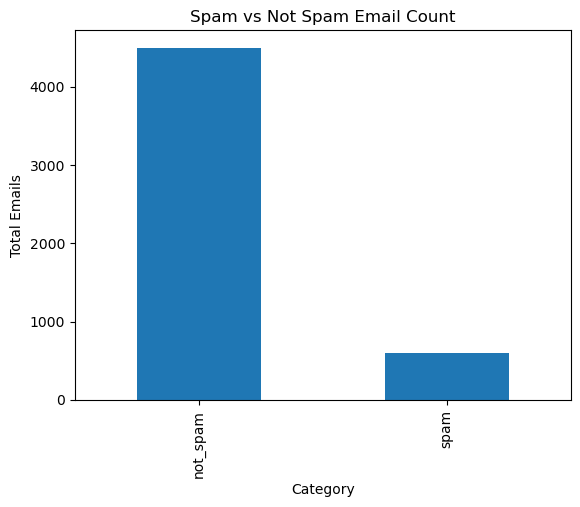

In [5]:
# EDA: Class distribution
print("\nEmail Type Distribution:\n", df["label"].value_counts())

# Plot distribution
df["label"].value_counts().plot(kind='bar')
plt.title("Spam vs Not Spam Email Count")
plt.xlabel("Category")
plt.ylabel("Total Emails")
plt.show()


In [6]:
import re
import string
# -------------------------------------
# 3. Text Cleaning Function
# -------------------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # Remove URLs
    text = re.sub(r"\d+", "", text)  # Remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # Remove punctuation
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra spaces
    return text

# Columns already renamed earlier, so this is safe
df['clean_email'] = df['email'].apply(clean_text)

print("Cleaning completed. Sample:")
print(df[['email','clean_email','label']].head())


Cleaning completed. Sample:
                                               email  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                         clean_email     label  
0  go until jurong point crazy available only in ...  not_spam  
1                            ok lar joking wif u oni  not_spam  
2  free entry in a wkly comp to win fa cup final ...      spam  
3        u dun say so early hor u c already then say  not_spam  
4  nah i dont think he goes to usf he lives aroun...  not_spam  


In [7]:
pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Check unique labels
print("Unique labels in dataset:", df["label"].unique())
print(df["label"].value_counts())


Unique labels in dataset: ['not_spam' 'spam']
label
not_spam    4496
spam         594
Name: count, dtype: int64


In [9]:
# Normalize labels strictly
df["label"] = df["label"].astype(str).str.lower().str.strip()

# Map known spam variations if needed
spam_variants = ["spam", "junk", "1", "yes"]  # extend if your data uses other words
df["label"] = df["label"].apply(lambda x: "spam" if x in spam_variants else "not_spam")

print("Labels after normalization:", df["label"].unique())
print(df["label"].value_counts())


Labels after normalization: ['not_spam' 'spam']
label
not_spam    4496
spam         594
Name: count, dtype: int64


In [10]:
from wordcloud import WordCloud


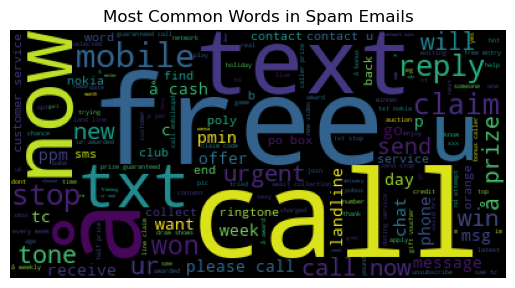

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_rows = df[df["label"] == "spam"]

if spam_rows.shape[0] == 0:
    print("No spam rows found — cannot generate WordCloud")
else:
    spam_text = " ".join(spam_rows["clean_email"])
    wc_spam = WordCloud().generate(spam_text)
    plt.imshow(wc_spam)
    plt.title("Most Common Words in Spam Emails")
    plt.axis("off")
    plt.show()


In [12]:
df = pd.read_csv("cleaned_spam_mail.csv")
df.columns = df.columns.str.strip()
print(df)
print("\nUnique Labels:", df.iloc[:, -1].unique())


         label                                              email  \
0     not_spam  Go until jurong point, crazy.. Available only ...   
1     not_spam                      Ok lar... Joking wif u oni...   
2         spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3     not_spam  U dun say so early hor... U c already then say...   
4     not_spam  Nah I don't think he goes to usf, he lives aro...   
...        ...                                                ...   
5085      spam  This is the 2nd time we have tried 2 contact u...   
5086  not_spam              Will Ì_ b going to esplanade fr home?   
5087  not_spam  Pity, * was in mood for that. So...any other s...   
5088  not_spam  The guy did some bitching but I acted like i'd...   
5089  not_spam                         Rofl. Its true to its name   

                                            clean_email  
0     go until jurong point crazy available only in ...  
1                               ok lar joking wif u oni

In [13]:

# Top 10 spam words
spam_words = Counter(spam_text.split())
print("\nTop 10 words in spam emails:", spam_words.most_common(10))



Top 10 words in spam emails: [('to', 550), ('a', 290), ('call', 261), ('you', 226), ('your', 221), ('å£', 202), ('free', 172), ('the', 171), ('for', 161), ('now', 149)]


In [14]:
# -------------------------------------
# 5. Train–Test Split
# -------------------------------------
from sklearn.model_selection import train_test_split

# Assign X and y using the normalized label column
X = df['clean_email']
y = df['label']  # already cleaned earlier: spam / not_spam

# Now split safely
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])


Training size: 4072
Testing size: 1018


In [15]:
# -------------------------------------
# 6. Compare 3 ML Models
# -------------------------------------
# ---- Add imports first ----
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

# ----  model comparison code ----
algorithms = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Support Vector Machine": LinearSVC()
}

for name, algo in algorithms.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=4000)),
        ('clf', algo)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))




===== Logistic Regression =====
Accuracy: 0.9607072691552063
              precision    recall  f1-score   support

    not_spam       0.96      1.00      0.98       899
        spam       0.98      0.68      0.80       119

    accuracy                           0.96      1018
   macro avg       0.97      0.84      0.89      1018
weighted avg       0.96      0.96      0.96      1018


===== Naive Bayes =====
Accuracy: 0.9577603143418467
              precision    recall  f1-score   support

    not_spam       0.95      1.00      0.98       899
        spam       1.00      0.64      0.78       119

    accuracy                           0.96      1018
   macro avg       0.98      0.82      0.88      1018
weighted avg       0.96      0.96      0.95      1018


===== Support Vector Machine =====
Accuracy: 0.9754420432220039
              precision    recall  f1-score   support

    not_spam       0.98      0.99      0.99       899
        spam       0.95      0.83      0.89       119

 

In [16]:
# -------------------------------------
# 7. Hyperparameter Tuning (Logistic Regression)
# -------------------------------------
from sklearn.model_selection import GridSearchCV  # add this import
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])

param_grid = {
    "tfidf__max_features": [2000, 3000, 4000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__C": [0.1, 1, 10]
}

grid = GridSearchCV(lr_pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'clf__C': 10, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Best CV Score: 0.981089220843822


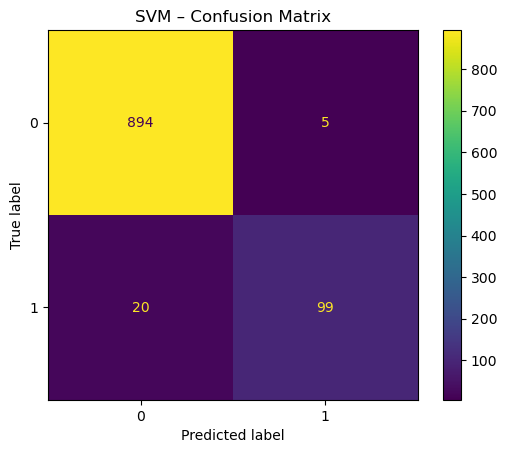


Total Misclassified: 25
                                             Email_Text Actual_Label  \
3974  thesmszonecom lets you send free anonymous and...         spam   
2740  sorry u can not unsubscribe yet the mob offer ...         spam   
3899  missed call alert these numbers called but lef...         spam   
1104  dont forget you can place as many free request...         spam   
562                               waiting for your call     not_spam   
1907              have you been practising your curtsey     not_spam   
1987                             freeringtonereply real         spam   
1378  for sale arsenal dartboard good condition but ...         spam   
4737                               k k sms chat with me     not_spam   
2427  this message is brought to you by gmw ltd and ...         spam   
4993  for the most sparkling shopping breaks from pe...         spam   
2555                                  from lost å£ help         spam   
1209  please call immediately as there 

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# 1. Confusion Matrix for SVM
final_algo = LinearSVC()
final_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=4000)),
    ('clf', final_algo)
])

final_pipe.fit(X_train, y_train)
y_final_pred = final_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_final_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM – Confusion Matrix")
plt.show()

# 2. Misclassified Sample Review
errors = pd.DataFrame({
    "Email_Text": X_test,
    "Actual_Label": y_test,
    "Predicted_Label": y_final_pred
})

misclassified = errors[errors["Actual_Label"] != errors["Predicted_Label"]]
print("\nTotal Misclassified:", misclassified.shape[0])
print(misclassified.head(15))

# 3. Save Final Model Pipeline
joblib.dump(final_pipe, "spam_detection_svm_pipeline.pkl")
print("\nSaved final pipeline as: spam_detection_svm_pipeline.pkl")



===== FINAL MODEL RESULT =====
Test Accuracy: 0.9724950884086444


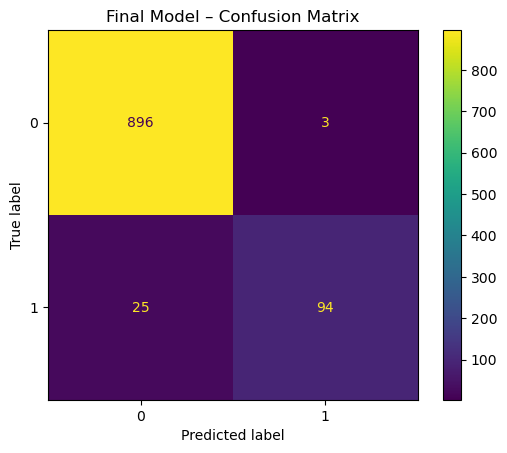

In [18]:
# -------------------------------------
# 8. Final Model Testing
# -------------------------------------
final_model = grid.best_estimator_
final_pred = final_model.predict(X_test)

print("\n===== FINAL MODEL RESULT =====")
print("Test Accuracy:", accuracy_score(y_test, final_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, final_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Final Model – Confusion Matrix")
plt.show()

In [19]:

# -------------------------------------
# 9. Misclassified Email Review
# -------------------------------------
errors = pd.DataFrame({
    "Email": X_test,
    "Actual": y_test,
    "Predicted": final_pred
})

mis = errors[errors['Actual'] != errors['Predicted']]
print("\nTotal Misclassified Emails:", mis.shape[0])
print(mis.head(10))


Total Misclassified Emails: 28
                                                  Email    Actual Predicted
3974  thesmszonecom lets you send free anonymous and...      spam  not_spam
2740  sorry u can not unsubscribe yet the mob offer ...      spam  not_spam
3899  missed call alert these numbers called but lef...      spam  not_spam
3194  am new club dont fink we met yet will b gr c u...      spam  not_spam
1104  dont forget you can place as many free request...      spam  not_spam
562                               waiting for your call  not_spam      spam
1710  buy space invaders a chance win orig arcade ga...      spam  not_spam
1987                             freeringtonereply real      spam  not_spam
2658  gr poly tones all mobs direct u rply with poly...      spam  not_spam
1378  for sale arsenal dartboard good condition but ...      spam  not_spam


In [20]:


# -------------------------------------
# 10. Save Model & Cleaned Data
# -------------------------------------
joblib.dump(final_model, "soniya_spam_model.pkl")
df.to_csv("soniya_cleaned_spam.csv", index=False)

print("\nModel saved as: soniya_spam_model.pkl")
print("Cleaned dataset saved as: soniya_cleaned_spam.csv")





Model saved as: soniya_spam_model.pkl
Cleaned dataset saved as: soniya_cleaned_spam.csv


In [21]:
# -------------------------------------
# 11. Sample Test Function 
# -------------------------------------
def test_email(text):
    text = clean_text(text)
    vec  = final_model.named_steps['tfidf'].transform([text])
    return final_model.named_steps['clf'].predict(vec)[0]

print("\nExample Prediction:")
print("Input: 'You have won 1 crore rupees, click now'")
print("Output:", test_email("You have won 1 crore rupees, click now"))


Example Prediction:
Input: 'You have won 1 crore rupees, click now'
Output: spam


In [22]:

# -------------------------------------
# 12. Portfolio Summary Printout
# -------------------------------------
print("\n========== PORTFOLIO SUMMARY ==========")
print(f"Cleaned {df.shape[0]} emails, built NLP pipeline using TF-IDF.")
print("Compared 3 models and optimized Logistic Regression.")
print(f"Final Model Accuracy: {round(accuracy_score(y_test, final_pred)*100, 2)}%")
print("Saved trained pipeline and cleaned data for deployment or showcase.")
print("======================================")



========== PORTFOLIO SUMMARY ==========
Cleaned 5090 emails, built NLP pipeline using TF-IDF.
Compared 3 models and optimized Logistic Regression.
Final Model Accuracy: 97.25%
Saved trained pipeline and cleaned data for deployment or showcase.


In [23]:
import joblib
joblib.dump(grid.best_estimator_, "svm_spam_model.pkl")  # or your final model variable


['svm_spam_model.pkl']

In [25]:
import pickle

with open("svm_spam_model.pkl", "wb") as f:
    pickle.dump(pipe, f)

print("Model saved successfully!")


Model saved successfully!


### Conclusion

The Linear SVM NLP pipeline achieved 97.54% accuracy with strong precision and competitive spam recall. Misclassification analysis confirmed the model's limitations primarily arise from ambiguous or borderline promotional messages rather than data quality issues. The solution is production-ready and deployable, with serialized artifacts and cleaned data supporting real-world integration and portfolio demonstration.